# Supplementary Figure 11B–E

Relational scores by target footprint, cell class, pathway membership, and selected representatives.

In [1]:
from pathlib import Path
from collections import defaultdict
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.stats import gaussian_kde
from IPython.display import display

%config InlineBackend.figure_format = "retina"

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src/manuscript_figures/figS11").exists():
    ROOT = ROOT.parent
if not (ROOT / "src/manuscript_figures/figS11").exists():
    raise FileNotFoundError("Run this notebook from the distributed_agent repository.")

S11 = ROOT / "src/manuscript_figures/figS11"
ANALYSIS = S11 / "analysis"

OI = {
    "blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
    "vermillion": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9",
    "yellow": "#F0E442", "grey": "#999999",
}
SCORE_LABEL = "relational score"

CELL_WHITELIST = {
    "001 L5-6 IT Glut", "005 L4-5 IT CTX Glut", "007 L2-3 IT CTX Glut",
    "008 L2-3 IT ENT PPP RSP Glut", "009 L2-3 IT PIR AON ENT Glut",
    "012 MEA LA CA1 DG Glut", "017 CA3 CA2-FC DG Glut", "022 L5 ET CTX Glut",
    "027 NP-CT-L6b-OB Glut", "046 CTX-CGE GABA", "052 Pvalb Gaba", "053 Sst Gaba",
    "054 CNU-MGE GABA", "059 CNU-LGE LSX GABA", "066 CNU-HYa HY GABA",
    "110 CNU-HYa HY MM Glut", "145 MH-LH TH Glut", "151 TH Prkcd Grin2c Glut",
    "155 MB Glut", "191 MB P MY GABA", "215 MB Dopa", "217 P MY Pineal Glut",
    "308 CB GABA",
}

plt.rcParams.update({
    # This notebook already contains a 24-inch multi-panel figure; 120 dpi
    # plus retina rendering keeps it crisp without creating an excessive bitmap.
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "svg.fonttype": "none",
})

In [2]:
findings = pd.read_csv(ANALYSIS / "analysis_table.csv").rename(columns={
    "evidence": "score",
    "winning_facet": "facet",
    "total_degs_padj_0.05": "footprint",
})
findings["cell_type_list"] = findings["cell_types"].fillna("").map(
    lambda value: [c.strip() for c in value.split("|") if c.strip() in CELL_WHITELIST]
)

membership = pd.read_parquet(
    ANALYSIS / "gene_membership.parquet",
    columns=["gene", "resource", "set_name"],
)
reference_pathways = pd.read_csv(ANALYSIS / "target_pathway_db_ranked.csv")
stories = pd.read_csv(
    ANALYSIS / "story_best_central_gene_top_relational_finding.tsv", sep="\t"
)
stories["score"] = stories["relational_proxy_score"].astype(float)
stories["final_rank"] = stories["story_rank"].astype(int)
stories["relational_rank"] = stories["relational_proxy_rank"].astype(int)
stories["is_exact"] = (
    stories["proxy_is_exact_central_anchor"].astype(str).str.lower().eq("true")
)
stories = stories.sort_values("final_rank").reset_index(drop=True)
summary = json.loads((ANALYSIS / "story_central_gene_top_relational_summary.json").read_text())

assert len(findings) == 3397
assert len(stories) == 144
assert findings["score"].notna().all()
assert set(c for values in findings["cell_type_list"] for c in values) <= CELL_WHITELIST
assert int(stories["is_exact"].sum()) == 26

pd.DataFrame({
    "quantity": [
        "relational findings", "canonical neuronal classes",
        "final stories", "exact story anchors", "same-gene proxies",
        "corpus median score", "corpus mean score", "maximum score",
    ],
    "value": [
        f"{len(findings):,}", len(CELL_WHITELIST), len(stories),
        int(stories["is_exact"].sum()), int((~stories["is_exact"]).sum()),
        f"{findings['score'].median():.4f}", f"{findings['score'].mean():.4f}",
        f"{findings['score'].max():.4f}",
    ],
})

,quantity,value
0,relational findings,"3,397"
1,canonical neuronal classes,23
2,final stories,144
3,exact story anchors,26
4,same-gene proxies,118
5,corpus median score,0.0504
6,corpus mean score,0.4588
7,maximum score,3.5346


In [3]:
def boxplot(ax, groups, colors, *, vert=False):
    """Original S11 convention: min–max whiskers, hidden fliers, black median."""
    bp = ax.boxplot(
        groups, vert=vert, patch_artist=True, widths=0.62,
        whis=(0, 100), showfliers=False,
        medianprops={"color": "black", "lw": 1.4},
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor("black")
        patch.set_linewidth(0.7)
    return bp


def draw_ridgeline(ax, labels, groups, color, *, xmax=None, overlap=0.92, bw=0.15):
    """Boundary-reflected KDE, peak-normalized independently within each row."""
    xmax = xmax if xmax is not None else max(float(np.max(g)) for g in groups)
    xs = np.linspace(0.0, xmax, 400)
    n = len(groups)
    for i, vals in enumerate(groups):
        vals = np.asarray(vals, dtype=float)
        try:
            dens = 2.0 * gaussian_kde(np.concatenate([vals, -vals]), bw_method=bw)(xs)
        except Exception:
            dens = np.zeros_like(xs)
        if dens.max() > 0:
            dens = dens / dens.max() * overlap
        ax.fill_between(
            xs, i, i + dens, color=color, alpha=0.72,
            edgecolor="black", linewidth=0.6, zorder=2 * (n - i),
        )
    ax.set_yticks([i + overlap / 2 for i in range(n)])
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.set_xlim(0, xmax)
    ax.set_ylim(-0.5, n - 1 + overlap + 0.2)
    ax.grid(axis="y", visible=False)


def short_pathway(name, width=52):
    name = str(name).strip()
    name = name[0:1].upper() + name[1:]
    return name if len(name) <= width else name[:width - 1] + "…"

## B — Score by response footprint and neuronal class

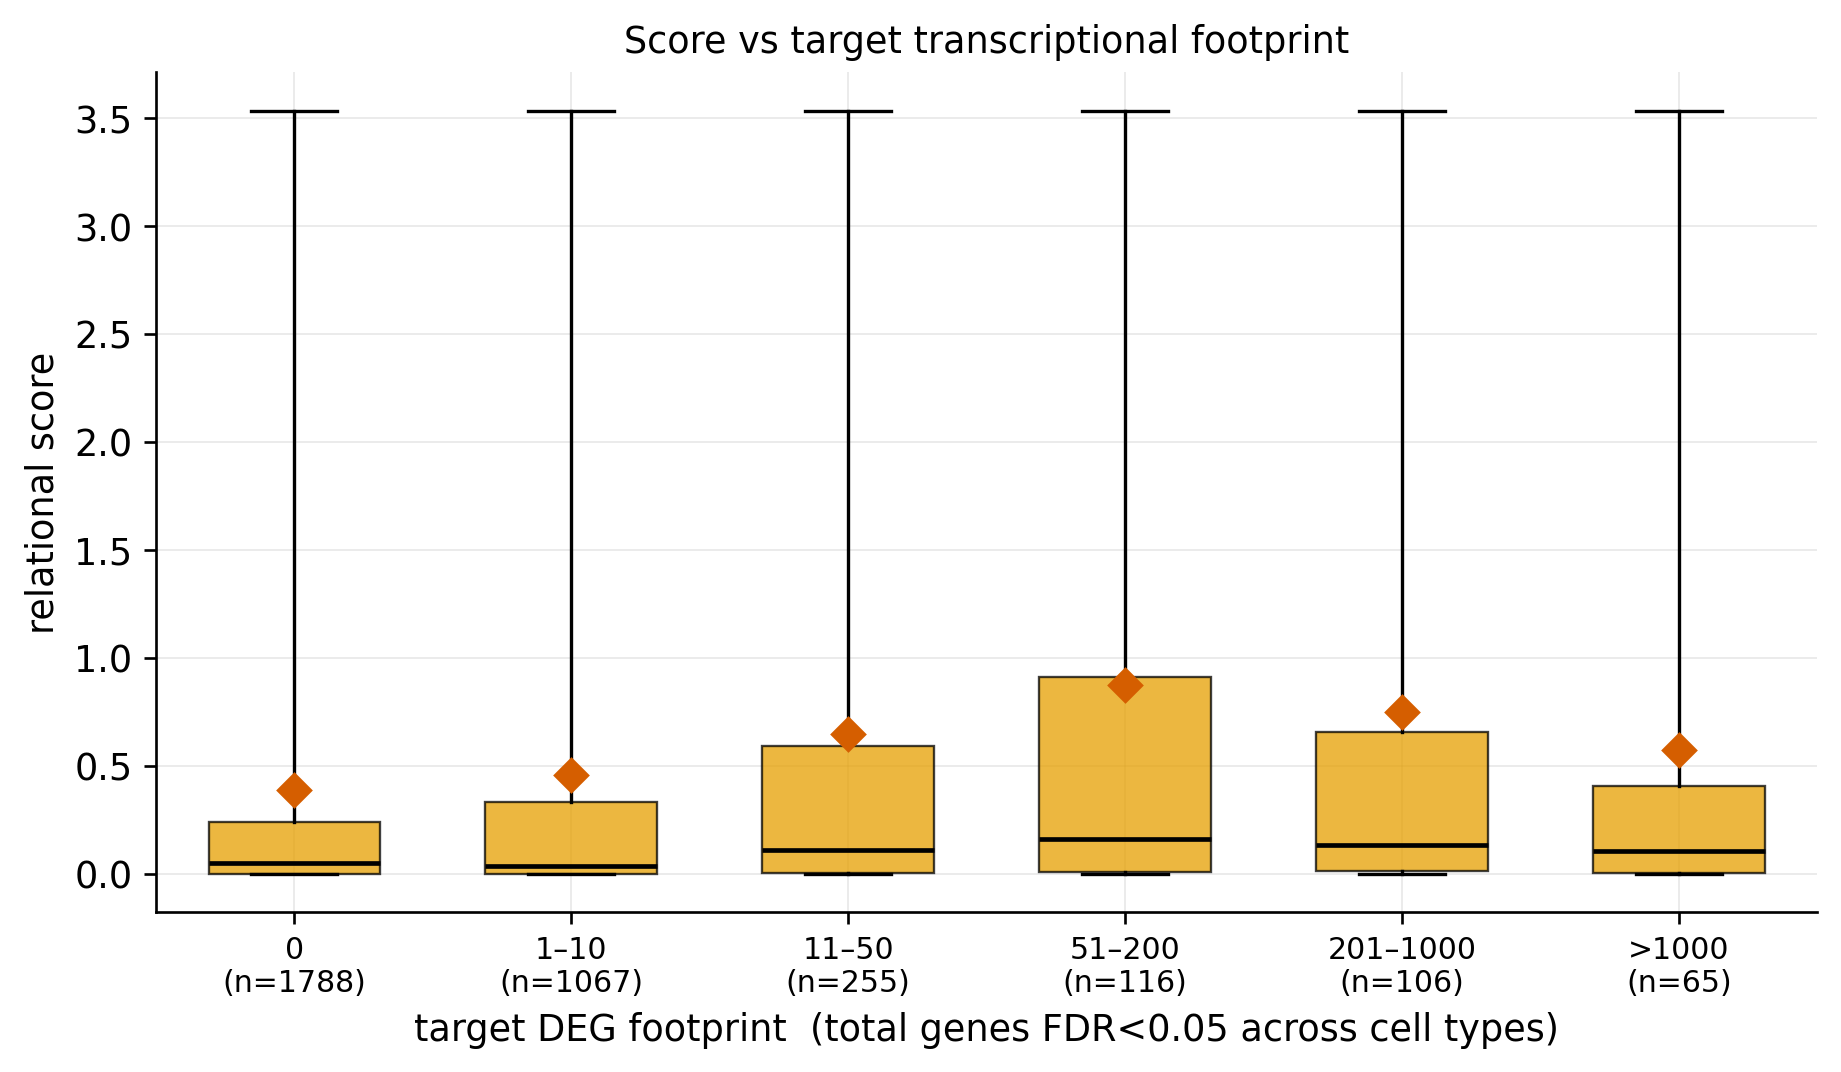

In [4]:
footprint_edges = [-0.5, 0.5, 10, 50, 200, 1000, np.inf]
footprint_labels = ["0", "1–10", "11–50", "51–200", "201–1000", ">1000"]
footprint_groups = [[] for _ in footprint_labels]
for row in findings.itertuples(index=False):
    if pd.isna(row.footprint):
        continue
    for i in range(len(footprint_labels)):
        if footprint_edges[i] < row.footprint <= footprint_edges[i + 1]:
            footprint_groups[i].append(row.score)
            break

footprint_counts = [len(g) for g in footprint_groups]
assert footprint_counts == [1788, 1067, 255, 116, 106, 65]

fig, ax = plt.subplots(figsize=(7.8, 4.6))
boxplot(ax, footprint_groups, [OI["orange"]] * len(footprint_groups), vert=True)
ax.set_xticks(range(1, len(footprint_labels) + 1))
ax.set_xticklabels(
    [f"{label}\n(n={count})" for label, count in zip(footprint_labels, footprint_counts)],
    fontsize=9,
)
ax.plot(
    range(1, len(footprint_groups) + 1),
    [np.mean(g) for g in footprint_groups],
    "D", color=OI["vermillion"], ms=7, zorder=5,
)
ax.set_xlabel("target DEG footprint  (total genes FDR<0.05 across cell types)")
ax.set_ylabel(SCORE_LABEL)
ax.set_title("Score vs target transcriptional footprint", fontsize=11)
fig.tight_layout()
plt.show()

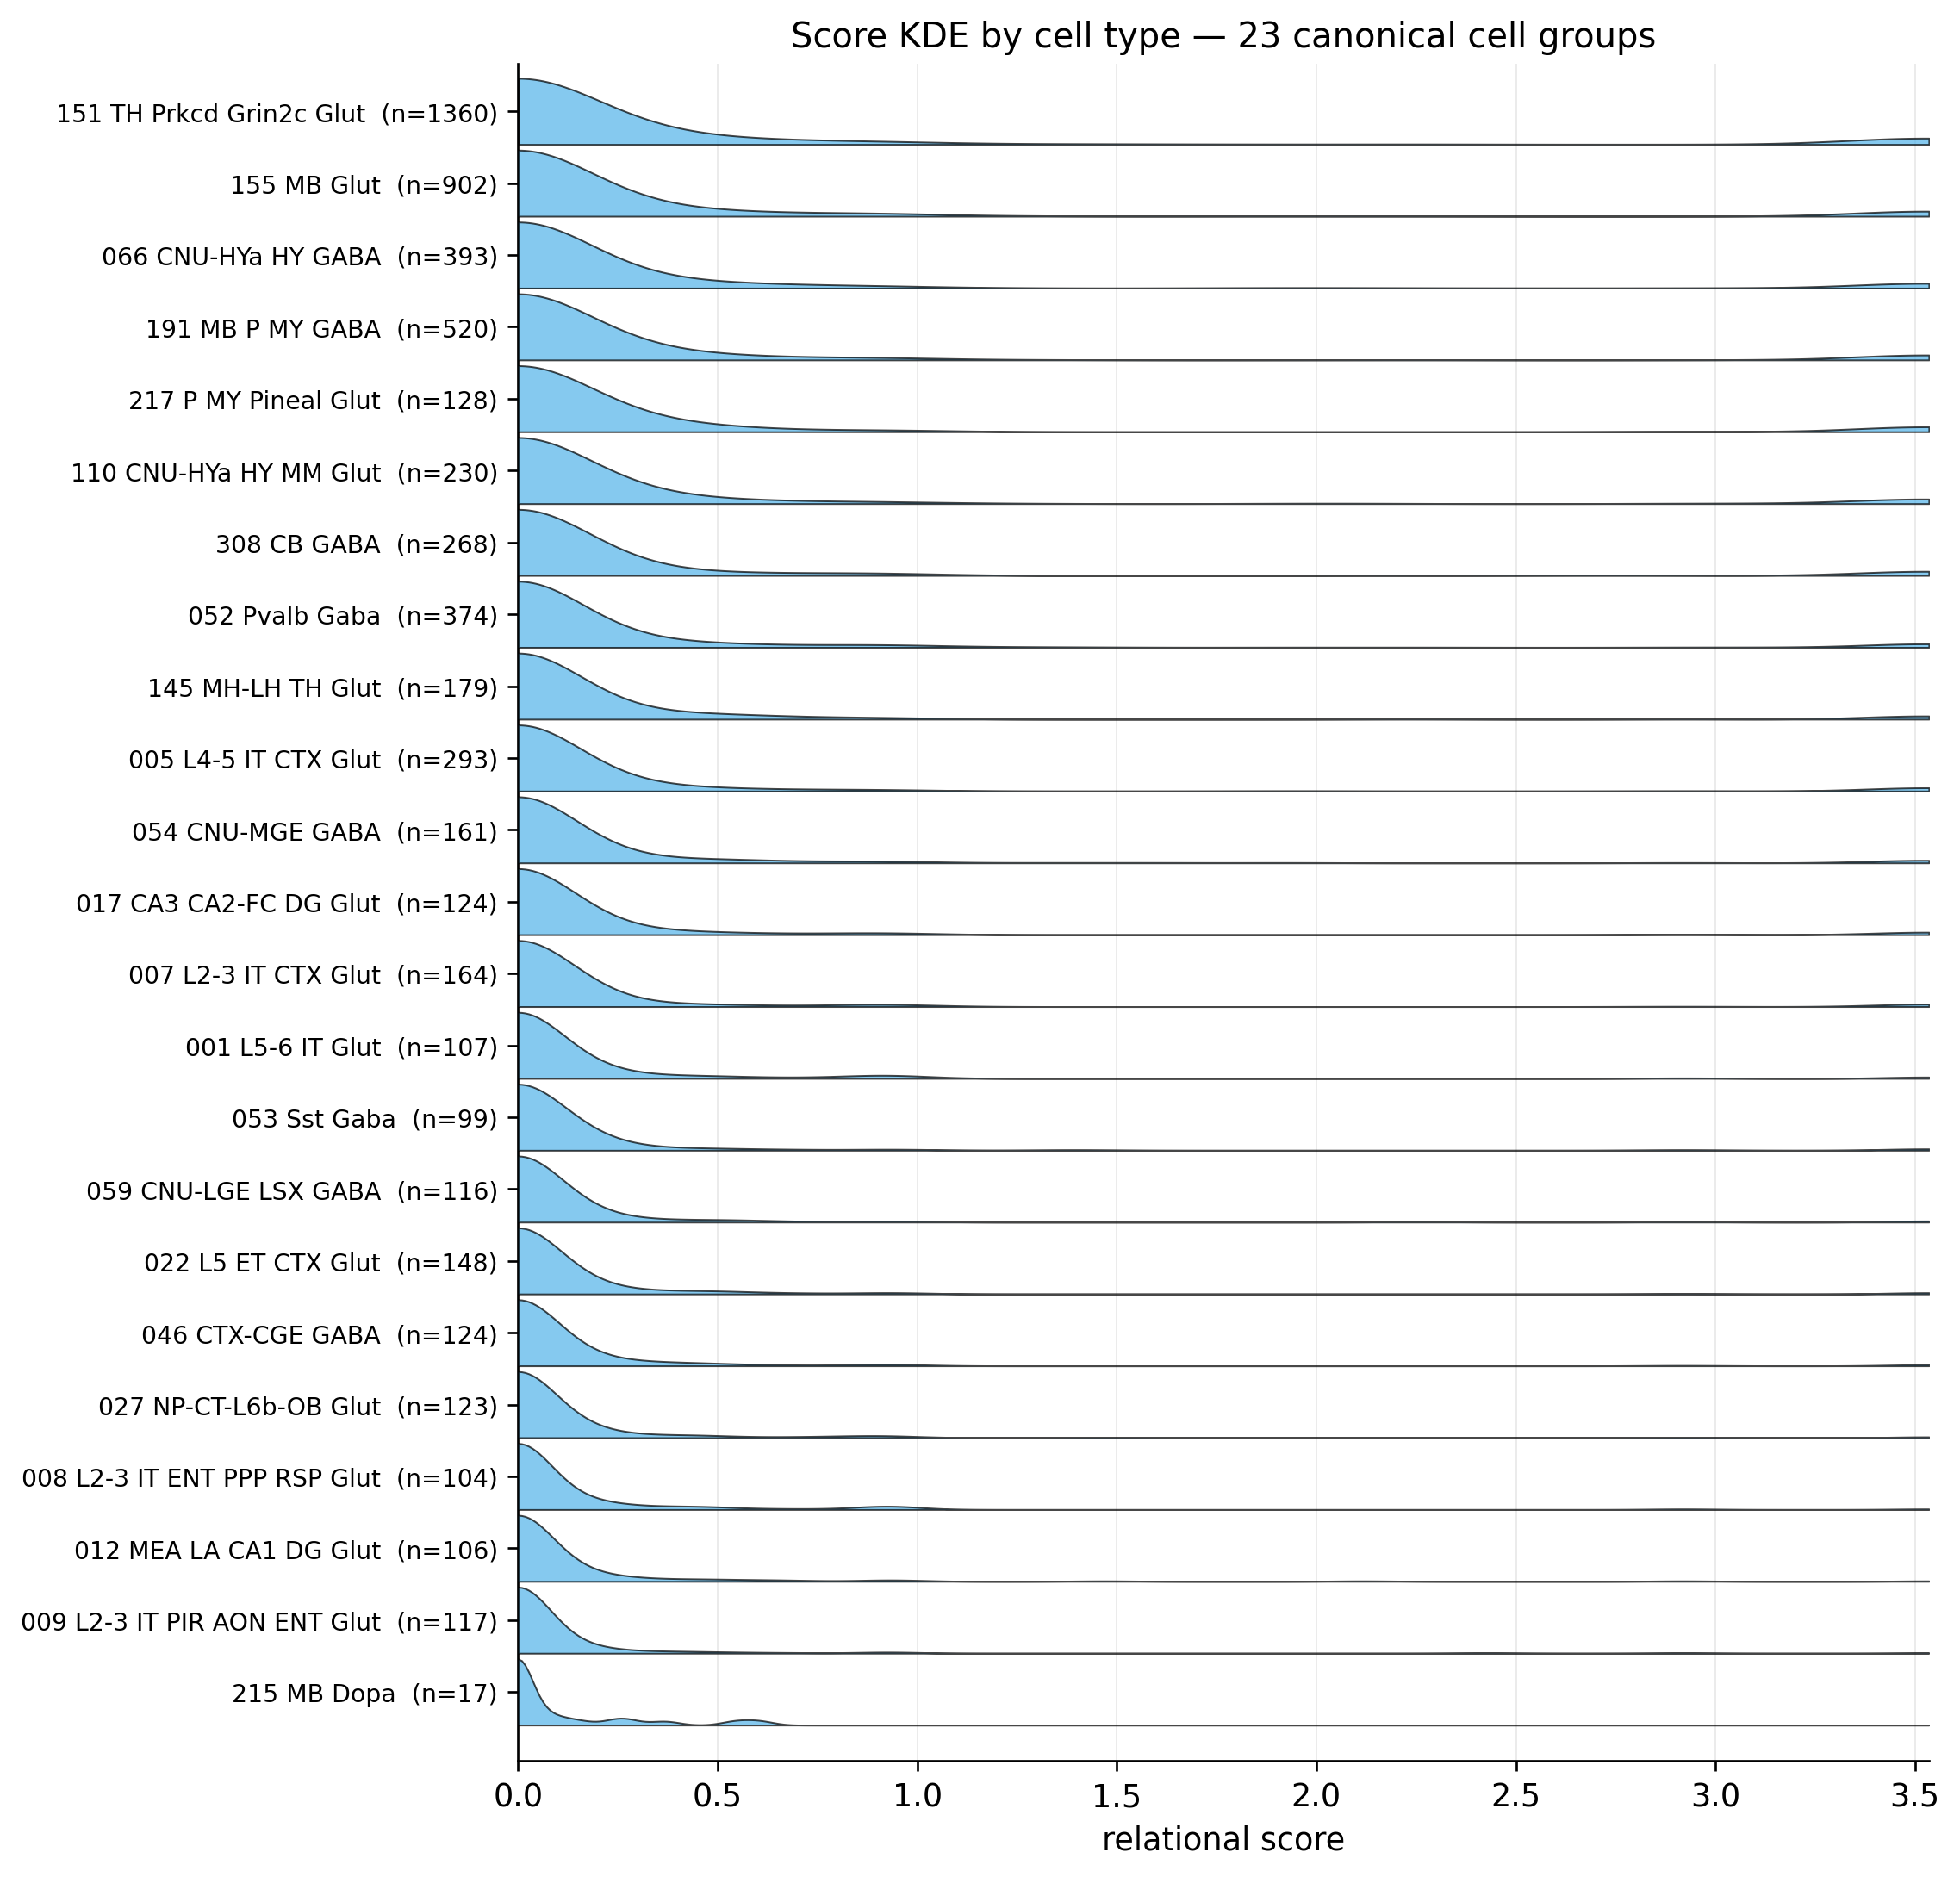

In [5]:
scores_by_cell = defaultdict(list)
for row in findings.itertuples(index=False):
    for cell_type in row.cell_type_list:
        scores_by_cell[cell_type].append(row.score)

cell_order = sorted(scores_by_cell, key=lambda c: len(scores_by_cell[c]), reverse=True)[:25]
cell_order = sorted(cell_order, key=lambda c: np.mean(scores_by_cell[c]))
cell_groups = [scores_by_cell[c] for c in cell_order]
cell_labels = [f"{c}  (n={len(scores_by_cell[c])})" for c in cell_order]
empty_cell_mentions = sum(not values for values in findings["cell_type_list"])

assert len(cell_order) == 23
assert empty_cell_mentions == 1489
assert [len(g) for g in cell_groups] == [
    17, 117, 106, 104, 123, 124, 148, 116, 99, 107, 164, 124,
    161, 293, 179, 374, 268, 230, 128, 520, 393, 902, 1360,
]

fig, ax = plt.subplots(figsize=(9.6, 9.2))
draw_ridgeline(ax, cell_labels, cell_groups, OI["sky"])
ax.set_xlabel(SCORE_LABEL)
ax.set_title(
    f"Score KDE by cell type — {len(cell_order)} canonical cell groups", fontsize=12,
)
fig.tight_layout()
plt.show()

## C — Pathway score distributions

In [6]:
scores_by_gene = findings.groupby("gene")["score"].apply(list).to_dict()
scored_genes = set(scores_by_gene)
overall_mean = float(findings["score"].mean())

library_specs = [
    ("GO:BP", "GO:BP", OI["blue"]),
    ("reactome", "Reactome", OI["green"]),
    ("MSigDB:MH", "Hallmark", OI["orange"]),
]
pathway_records = []
top_pathways = {}
for resource, library, color in library_specs:
    recs = []
    sub = membership[membership["resource"].eq(resource)]
    for set_name, group in sub.groupby("set_name"):
        genes = set(group["gene"]) & scored_genes
        if len(genes) < 10:
            continue
        vals = [score for gene in genes for score in scores_by_gene[gene]]
        if len(vals) < 25:
            continue
        rec = (float(np.mean(vals)), len(genes), vals, str(set_name).strip())
        recs.append(rec)
    recs.sort(key=lambda item: item[0], reverse=True)
    for rec in recs:
        pathway_records.append({
            "library": library, "pathway": rec[3], "n_targets": rec[1],
            "n_findings": len(rec[2]), "mean_score": round(rec[0], 4),
        })
    top_pathways[library] = recs[:15][::-1]  # ascending on axis; best appears at top

reconstructed_pathways = pd.DataFrame(pathway_records)
comparison = reference_pathways.merge(
    reconstructed_pathways,
    on=["library", "pathway"], how="outer", suffixes=("_reference", "_reconstructed"),
    indicator=True,
)
assert len(reference_pathways) == len(reconstructed_pathways) == 800
assert comparison["_merge"].eq("both").all()
assert comparison["n_targets_reference"].eq(comparison["n_targets_reconstructed"]).all()
assert comparison["n_findings_reference"].eq(comparison["n_findings_reconstructed"]).all()
assert np.max(np.abs(
    comparison["mean_score_reference"] - comparison["mean_score_reconstructed"]
)) <= 0.00011
for library in ["GO:BP", "Reactome", "Hallmark"]:
    reference_order = reference_pathways.loc[
        reference_pathways["library"].eq(library), "pathway"
    ].tolist()
    rebuilt_order = reconstructed_pathways.loc[
        reconstructed_pathways["library"].eq(library), "pathway"
    ].tolist()
    assert reference_order == rebuilt_order

pd.DataFrame({
    "library": ["GO:BP", "Reactome", "Hallmark"],
    "eligible sets": [
        int((reconstructed_pathways["library"] == lib).sum())
        for lib in ["GO:BP", "Reactome", "Hallmark"]
    ],
    "top-set mean": [
        f"{max(r[0] for r in top_pathways[lib]):.4f}"
        for lib in ["GO:BP", "Reactome", "Hallmark"]
    ],
})

,library,eligible sets,top-set mean
0,GO:BP,500,1.0699
1,Reactome,263,1.2775
2,Hallmark,37,1.1242


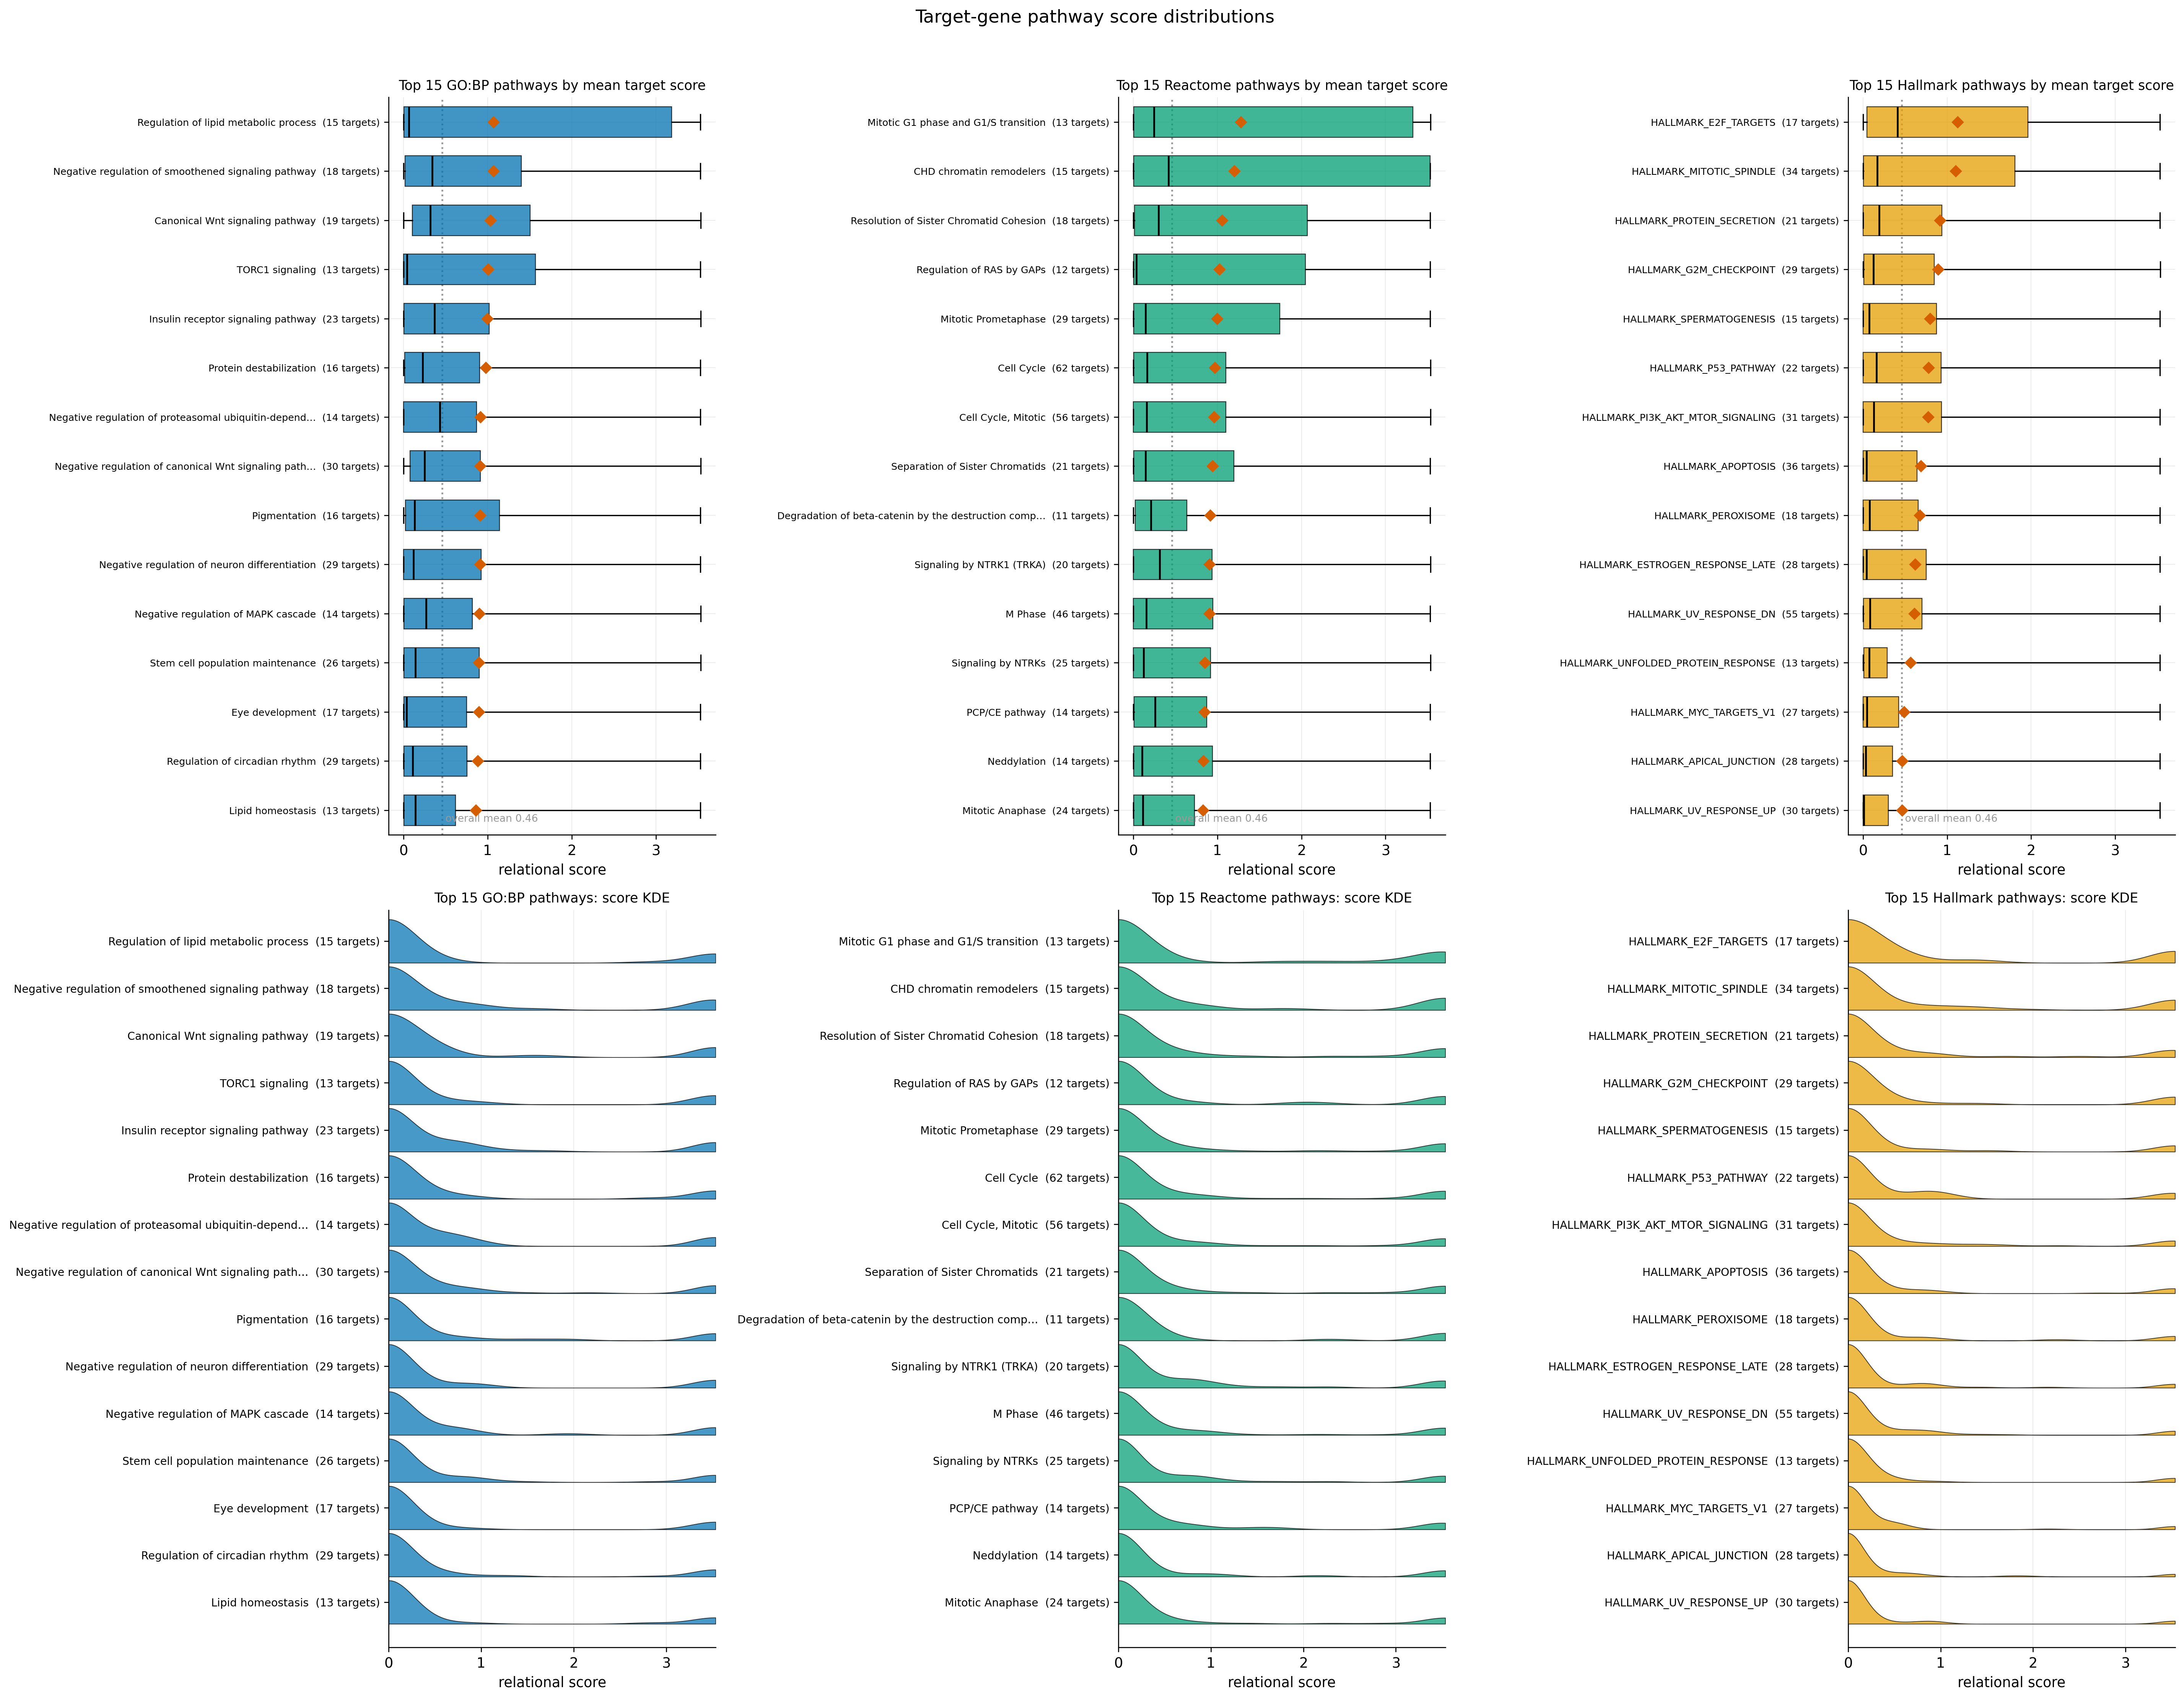

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(24, 18.5))
for col, (_resource, library, color) in enumerate(library_specs):
    top = top_pathways[library]
    groups = [item[2] for item in top]
    labels = [f"{short_pathway(item[3])}  ({item[1]} targets)" for item in top]

    ax = axes[0, col]
    boxplot(ax, groups, [color] * len(groups), vert=False)
    ax.plot(
        [np.mean(g) for g in groups], range(1, len(groups) + 1),
        "D", color=OI["vermillion"], ms=6, zorder=5,
    )
    ax.set_yticks(range(1, len(groups) + 1))
    ax.set_yticklabels(labels, fontsize=7.6)
    ax.axvline(overall_mean, color=OI["grey"], ls=":", lw=1.4, zorder=1)
    ax.text(
        overall_mean, 0.015, f" overall mean {overall_mean:.2f}",
        color=OI["grey"], fontsize=8, ha="left", va="bottom",
        transform=ax.get_xaxis_transform(),
    )
    ax.set_xlabel(SCORE_LABEL)
    ax.set_title(f"Top 15 {library} pathways by mean target score", fontsize=10.5)

    ax = axes[1, col]
    draw_ridgeline(ax, labels, groups, color)
    ax.set_xlabel(SCORE_LABEL)
    ax.set_title(f"Top 15 {library} pathways: score KDE", fontsize=10.5)

fig.suptitle("Target-gene pathway score distributions", y=0.998, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

## D — Score across neuronal classes

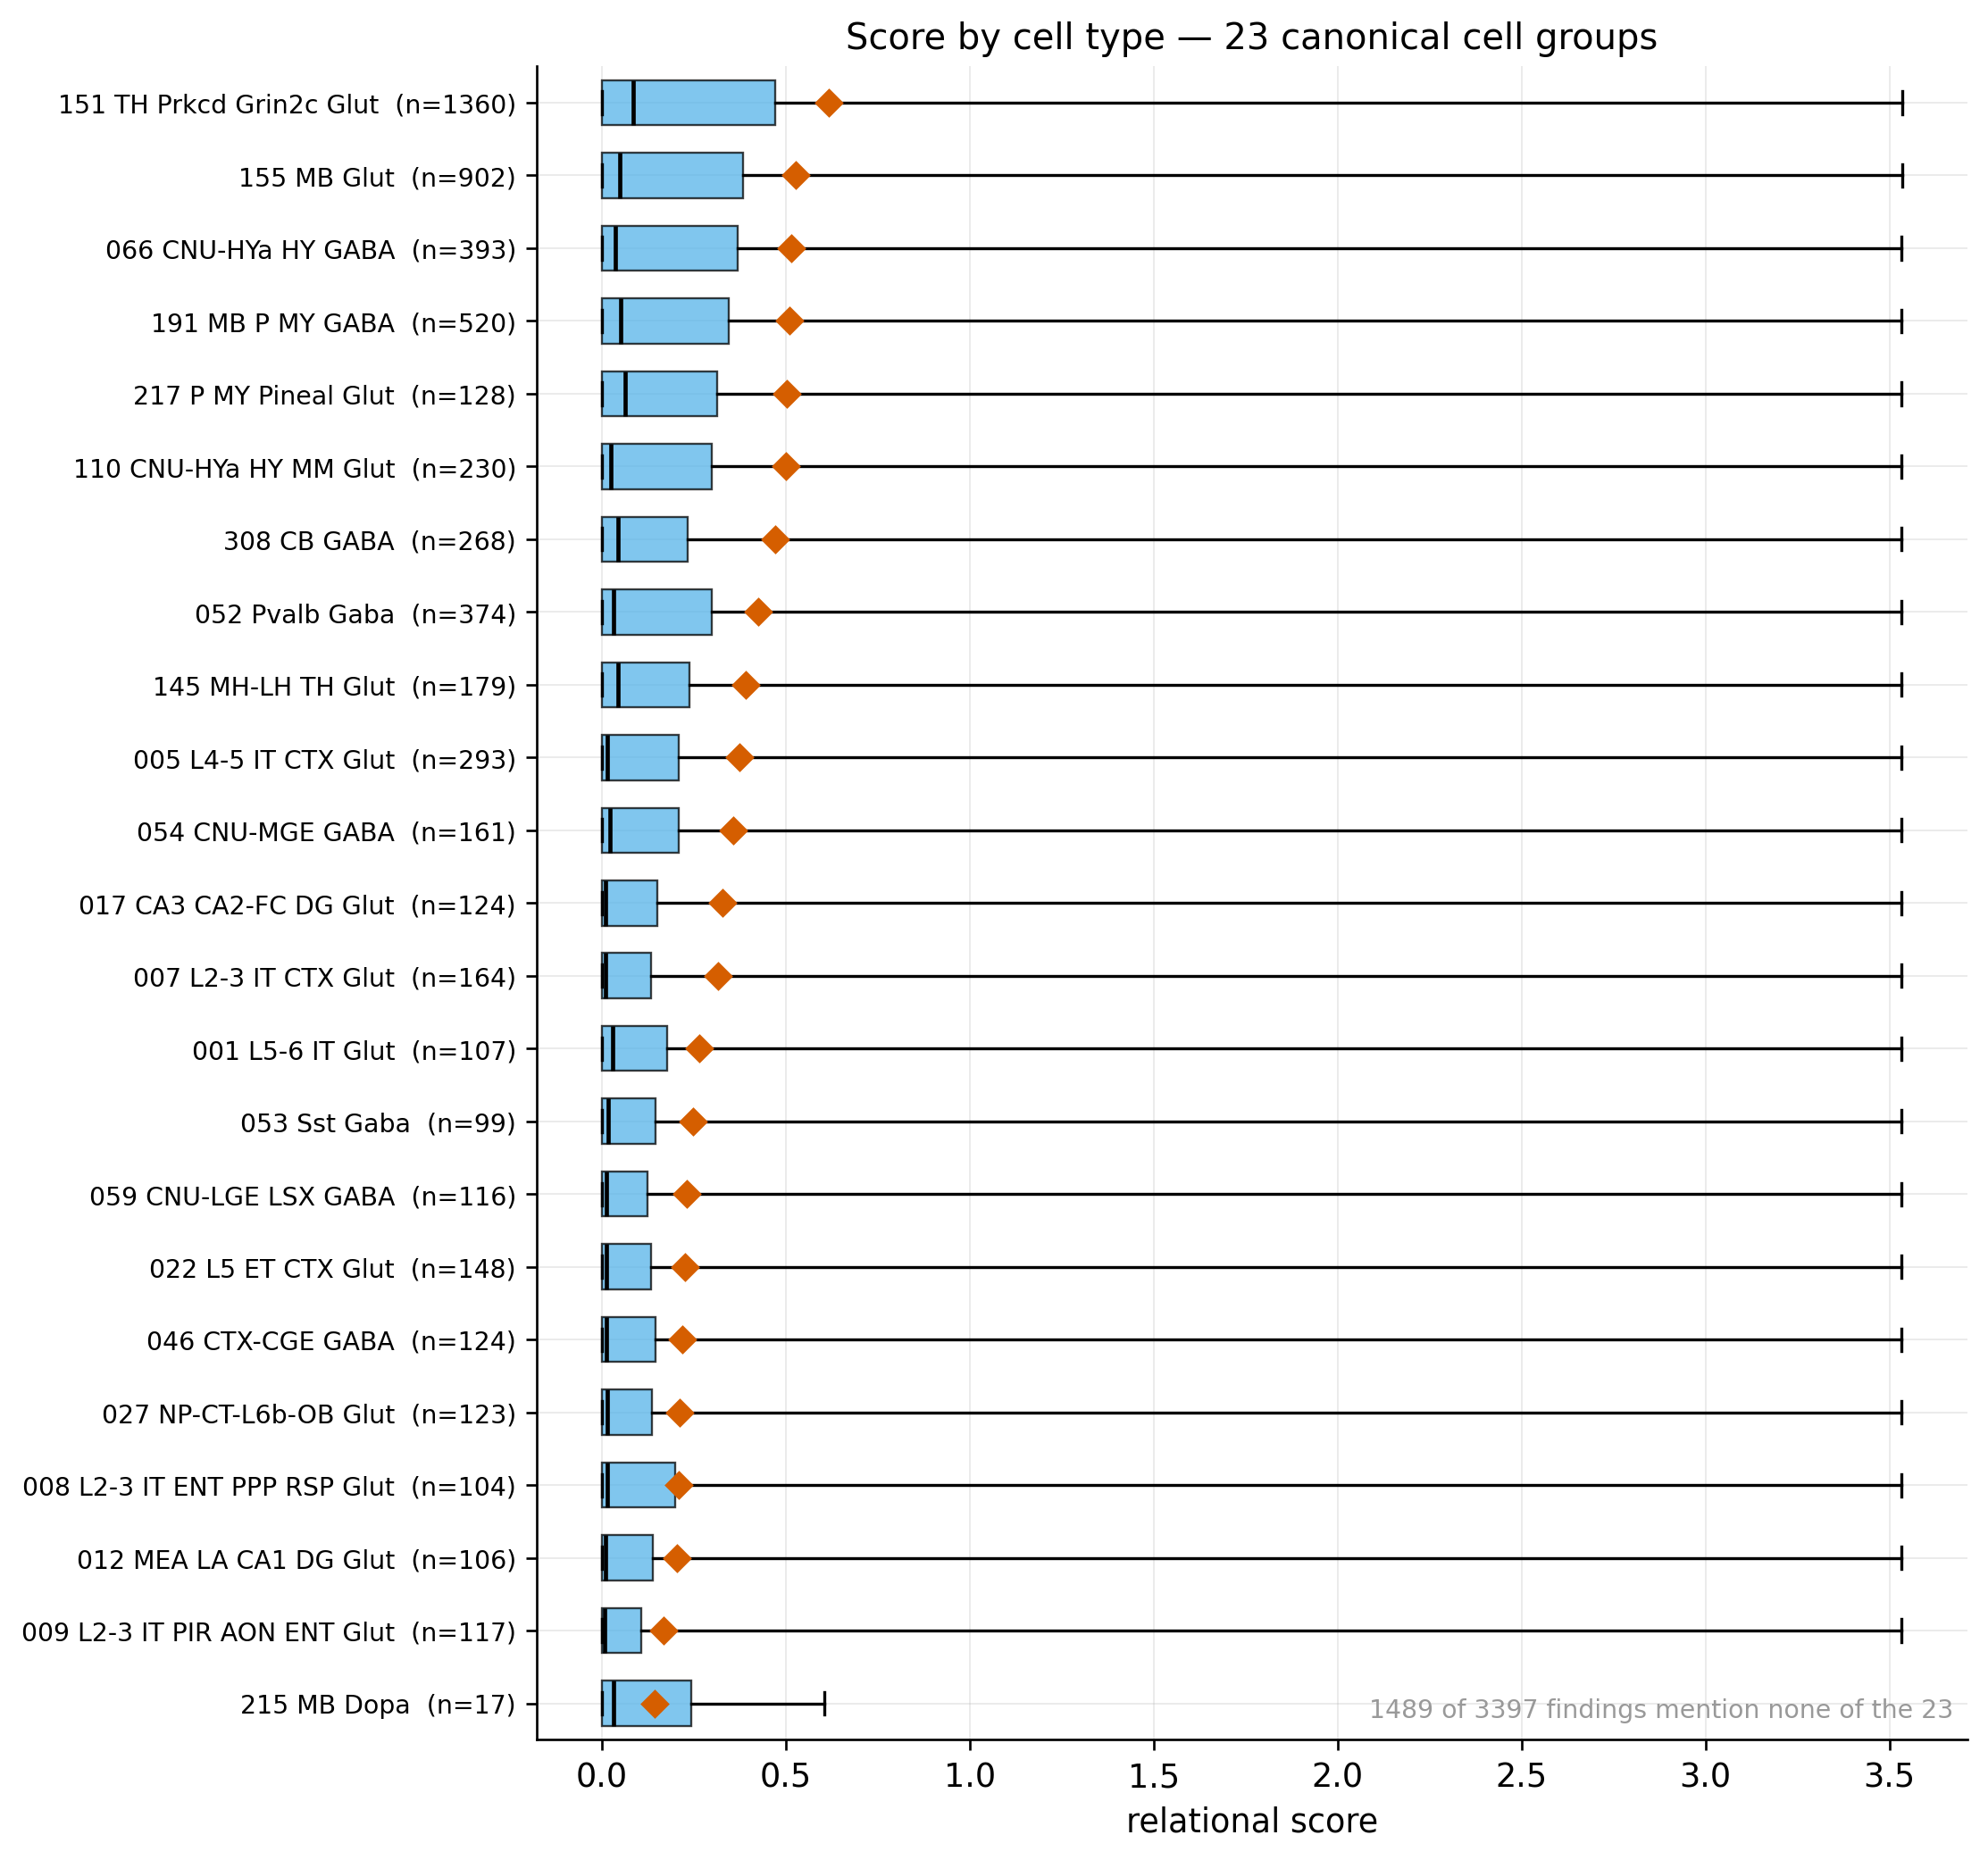

In [8]:
fig, ax = plt.subplots(figsize=(9.4, 8.8))
boxplot(ax, cell_groups, [OI["sky"]] * len(cell_groups), vert=False)
ax.plot(
    [np.mean(g) for g in cell_groups], range(1, len(cell_groups) + 1),
    "D", color=OI["vermillion"], ms=6, zorder=5,
)
ax.set_yticks(range(1, len(cell_groups) + 1))
ax.set_yticklabels(cell_labels, fontsize=8.5)
ax.set_xlabel(SCORE_LABEL)
ax.set_title(
    f"Score by cell type — {len(cell_groups)} canonical cell groups", fontsize=12,
)
ax.text(
    0.99, 0.01,
    f"{empty_cell_mentions} of {len(findings)} findings mention none of the {len(CELL_WHITELIST)}",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color=OI["grey"],
)
fig.tight_layout()
plt.show()

## E — Selected representatives in the score distribution

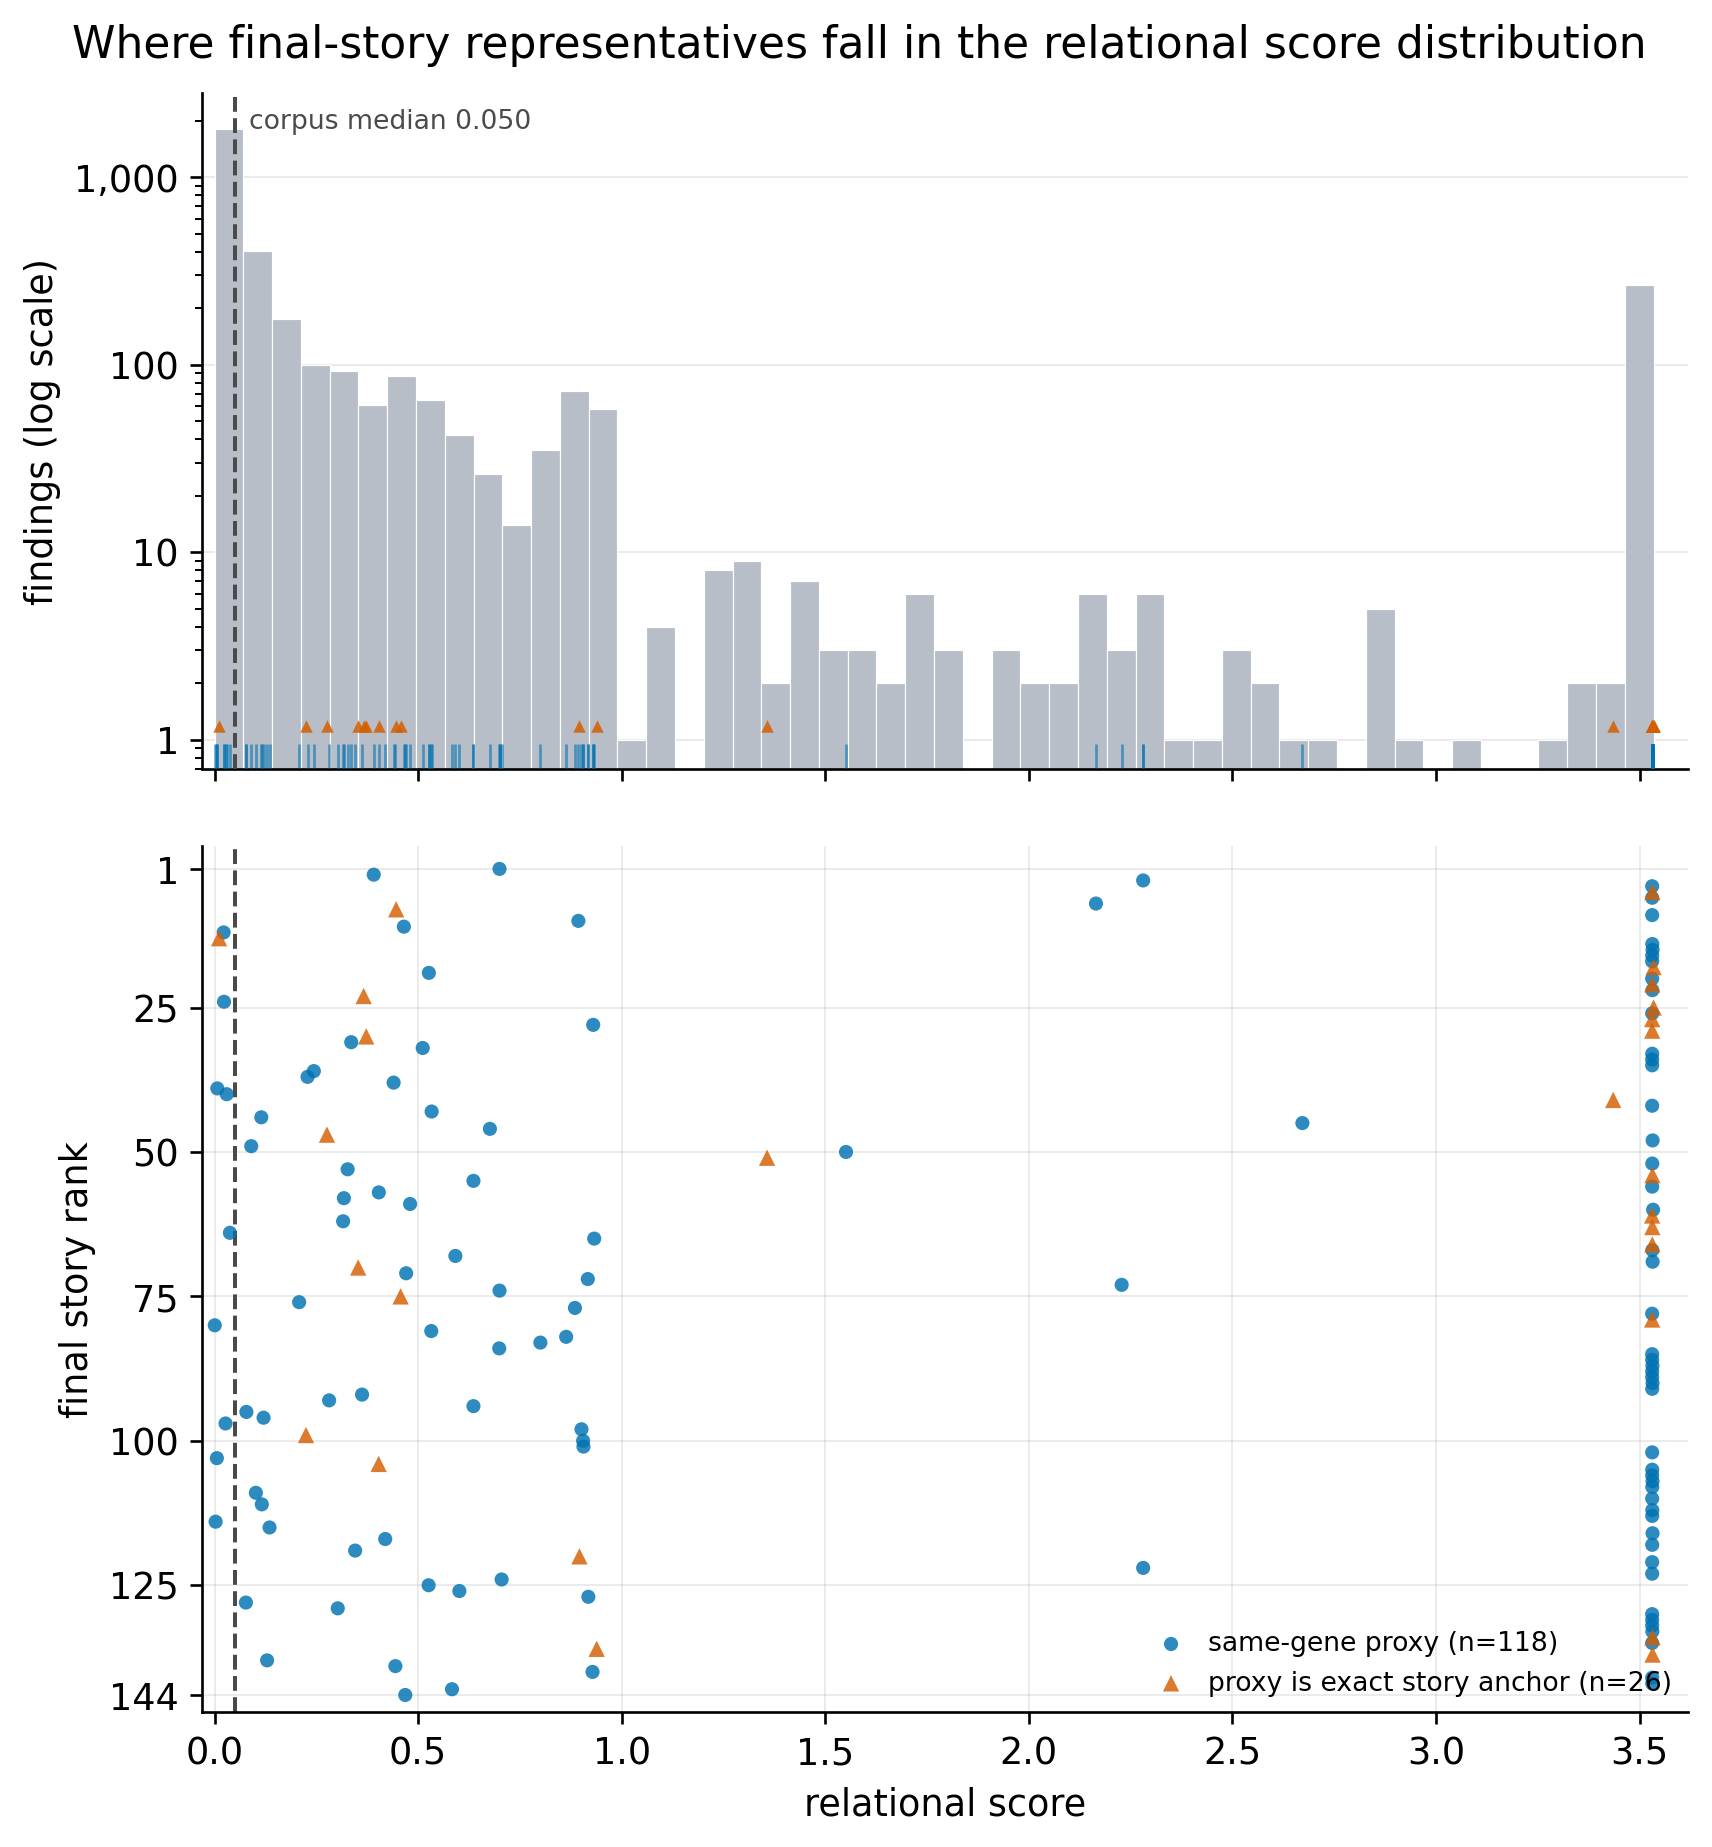

In [9]:
STORY_COLORS = {
    "hist": "#B8BEC7", "hist_edge": "#FFFFFF", "proxy": "#0072B2",
    "anchor": "#D55E00", "median": "#4A4A4A", "grid": "#DDDDDD",
}


def configure_score_axis(ax, show_label=True):
    ax.set_xlim(-0.03, 3.62)
    ax.set_xticks(np.arange(0, 3.6, 0.5))
    if show_label:
        ax.set_xlabel(SCORE_LABEL)


def draw_story_histogram(ax, scores, story_table):
    bins = np.linspace(0, scores.max(), 51)
    counts, edges = np.histogram(scores, bins=bins)
    baseline = 0.7
    ax.bar(
        edges[:-1], np.clip(counts - baseline, 0, None), width=np.diff(edges),
        align="edge", bottom=baseline, color=STORY_COLORS["hist"],
        edgecolor=STORY_COLORS["hist_edge"], linewidth=0.35, zorder=1,
    )
    ax.set_yscale("log")
    ax.set_ylim(baseline, counts.max() * 1.55)
    ax.yaxis.set_major_locator(FixedLocator([1, 10, 100, 1000]))
    ax.yaxis.set_major_formatter(FixedFormatter(["1", "10", "100", "1,000"]))
    median = float(np.median(scores))
    ax.axvline(median, color=STORY_COLORS["median"], lw=1.2, ls="--", zorder=3)
    proxy_scores = story_table.loc[~story_table["is_exact"], "score"]
    anchor_scores = story_table.loc[story_table["is_exact"], "score"]
    ax.scatter(
        proxy_scores, np.full(len(proxy_scores), 0.82), marker="|", s=55,
        linewidths=0.8, color=STORY_COLORS["proxy"], alpha=0.60,
        clip_on=False, zorder=4,
    )
    ax.scatter(
        anchor_scores, np.full(len(anchor_scores), 1.18), marker="^", s=14,
        linewidths=0, color=STORY_COLORS["anchor"], alpha=0.85,
        clip_on=False, zorder=5,
    )
    ax.text(
        median + 0.035, counts.max() * 1.28, f"corpus median {median:.3f}",
        color=STORY_COLORS["median"], fontsize=8, ha="left", va="top",
    )
    ax.set_ylabel("findings (log scale)")
    configure_score_axis(ax, show_label=False)
    ax.grid(axis="x", visible=False)


def draw_story_map(ax, scores, story_table):
    median = float(np.median(scores))
    ax.axvline(median, color=STORY_COLORS["median"], lw=1.2, ls="--", zorder=1)
    for is_exact, marker, color, label in [
        (False, "o", STORY_COLORS["proxy"], "same-gene proxy"),
        (True, "^", STORY_COLORS["anchor"], "proxy is exact story anchor"),
    ]:
        group = story_table[story_table["is_exact"].eq(is_exact)]
        ax.scatter(
            group["score"], group["final_rank"], marker=marker,
            s=18 if not is_exact else 24, color=color, edgecolors="none",
            alpha=0.82, clip_on=False, label=f"{label} (n={len(group)})", zorder=3,
        )
    ax.set_ylim(147, -3)
    ax.set_yticks([1, 25, 50, 75, 100, 125, 144])
    ax.set_ylabel("final story rank")
    configure_score_axis(ax, show_label=True)
    ax.legend(loc="lower right", frameon=False, fontsize=8, handletextpad=0.4, borderaxespad=0.2)

scores = findings["score"].to_numpy(dtype=float)
fig = plt.figure(figsize=(7.2, 7.8))
grid = fig.add_gridspec(2, 1, height_ratios=[0.92, 1.18], hspace=0.10)
ax_hist = fig.add_subplot(grid[0])
ax_map = fig.add_subplot(grid[1], sharex=ax_hist)
draw_story_histogram(ax_hist, scores, stories)
draw_story_map(ax_map, scores, stories)
ax_hist.tick_params(axis="x", labelbottom=False)
fig.suptitle(
    "Where final-story representatives fall in the relational score distribution", y=0.992
)
fig.subplots_adjust(left=0.12, right=0.98, top=0.955, bottom=0.09)
plt.show()